# 00 - Exploration de la base de données "Cars"

**Objectifs de ce notebook :**
1. Vérifier que les données sont bien téléchargées et accessibles.
2. Analyser la distribution des 14 167 images dans les 10 classes.
3. Visualiser les images de requêtes spécifiques (R1 à R15).

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

%matplotlib inline

## 1. Configuration des chemins

Assurez-vous d'avoir extrait le dossier "Cars" téléchargé depuis Nextcloud dans le dossier `data/raw/` de votre projet.

In [2]:
DATA_DIR = "../data/raw/Cars"

if not os.path.exists(DATA_DIR):
    print(f"ERREUR : Le dossier {DATA_DIR} est introuvable.")
    print("Veuillez télécharger les données et les placer au bon endroit.")
else:
    classes = sorted(os.listdir(DATA_DIR))
    print(f"Dossier trouvé ! Il contient {len(classes)} images.")

Dossier trouvé ! Il contient 10000 images.


## 2. Distribution des images par classe

Nous allons compter combien d'images se trouvent dans chaque classe pour vérifier s'il y a un déséquilibre dans le dataset.

Nombre total d'images : 10000 (Attendu : 14 167)


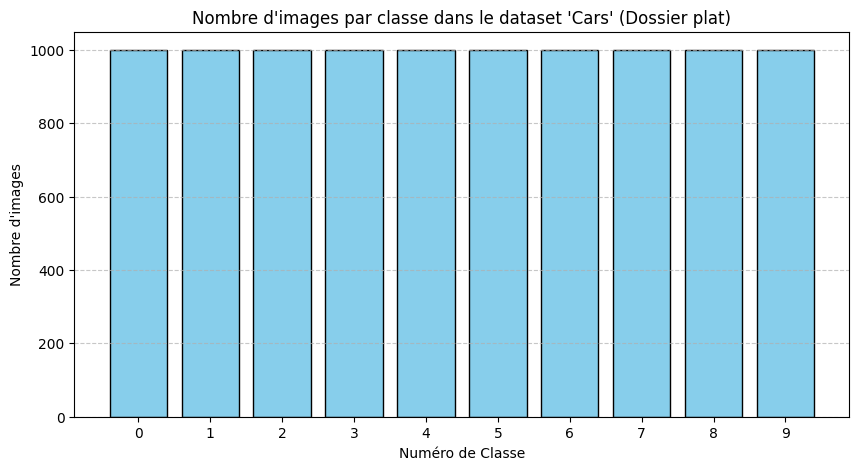

In [3]:
from collections import Counter

all_images = [f for f in os.listdir(DATA_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
total_images = len(all_images)

classes_extracted = [filename.split('_')[0] for filename in all_images]

class_counts = Counter(classes_extracted)

sorted_classes = sorted(class_counts.keys(), key=int)
sorted_counts = [class_counts[c] for c in sorted_classes]

print(f"Nombre total d'images : {total_images} (Attendu : 14 167)")

plt.figure(figsize=(10, 5))
plt.bar(sorted_classes, sorted_counts, color='skyblue', edgecolor='black')
plt.title("Nombre d'images par classe dans le dataset 'Cars' (Dossier plat)")
plt.xlabel("Numéro de Classe")
plt.ylabel("Nombre d'images")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Visualisation des requêtes (Classes 0, 2, 4, 6, 8)

Voici les images qui serviront de base (requêtes) pour tester notre moteur de recherche.

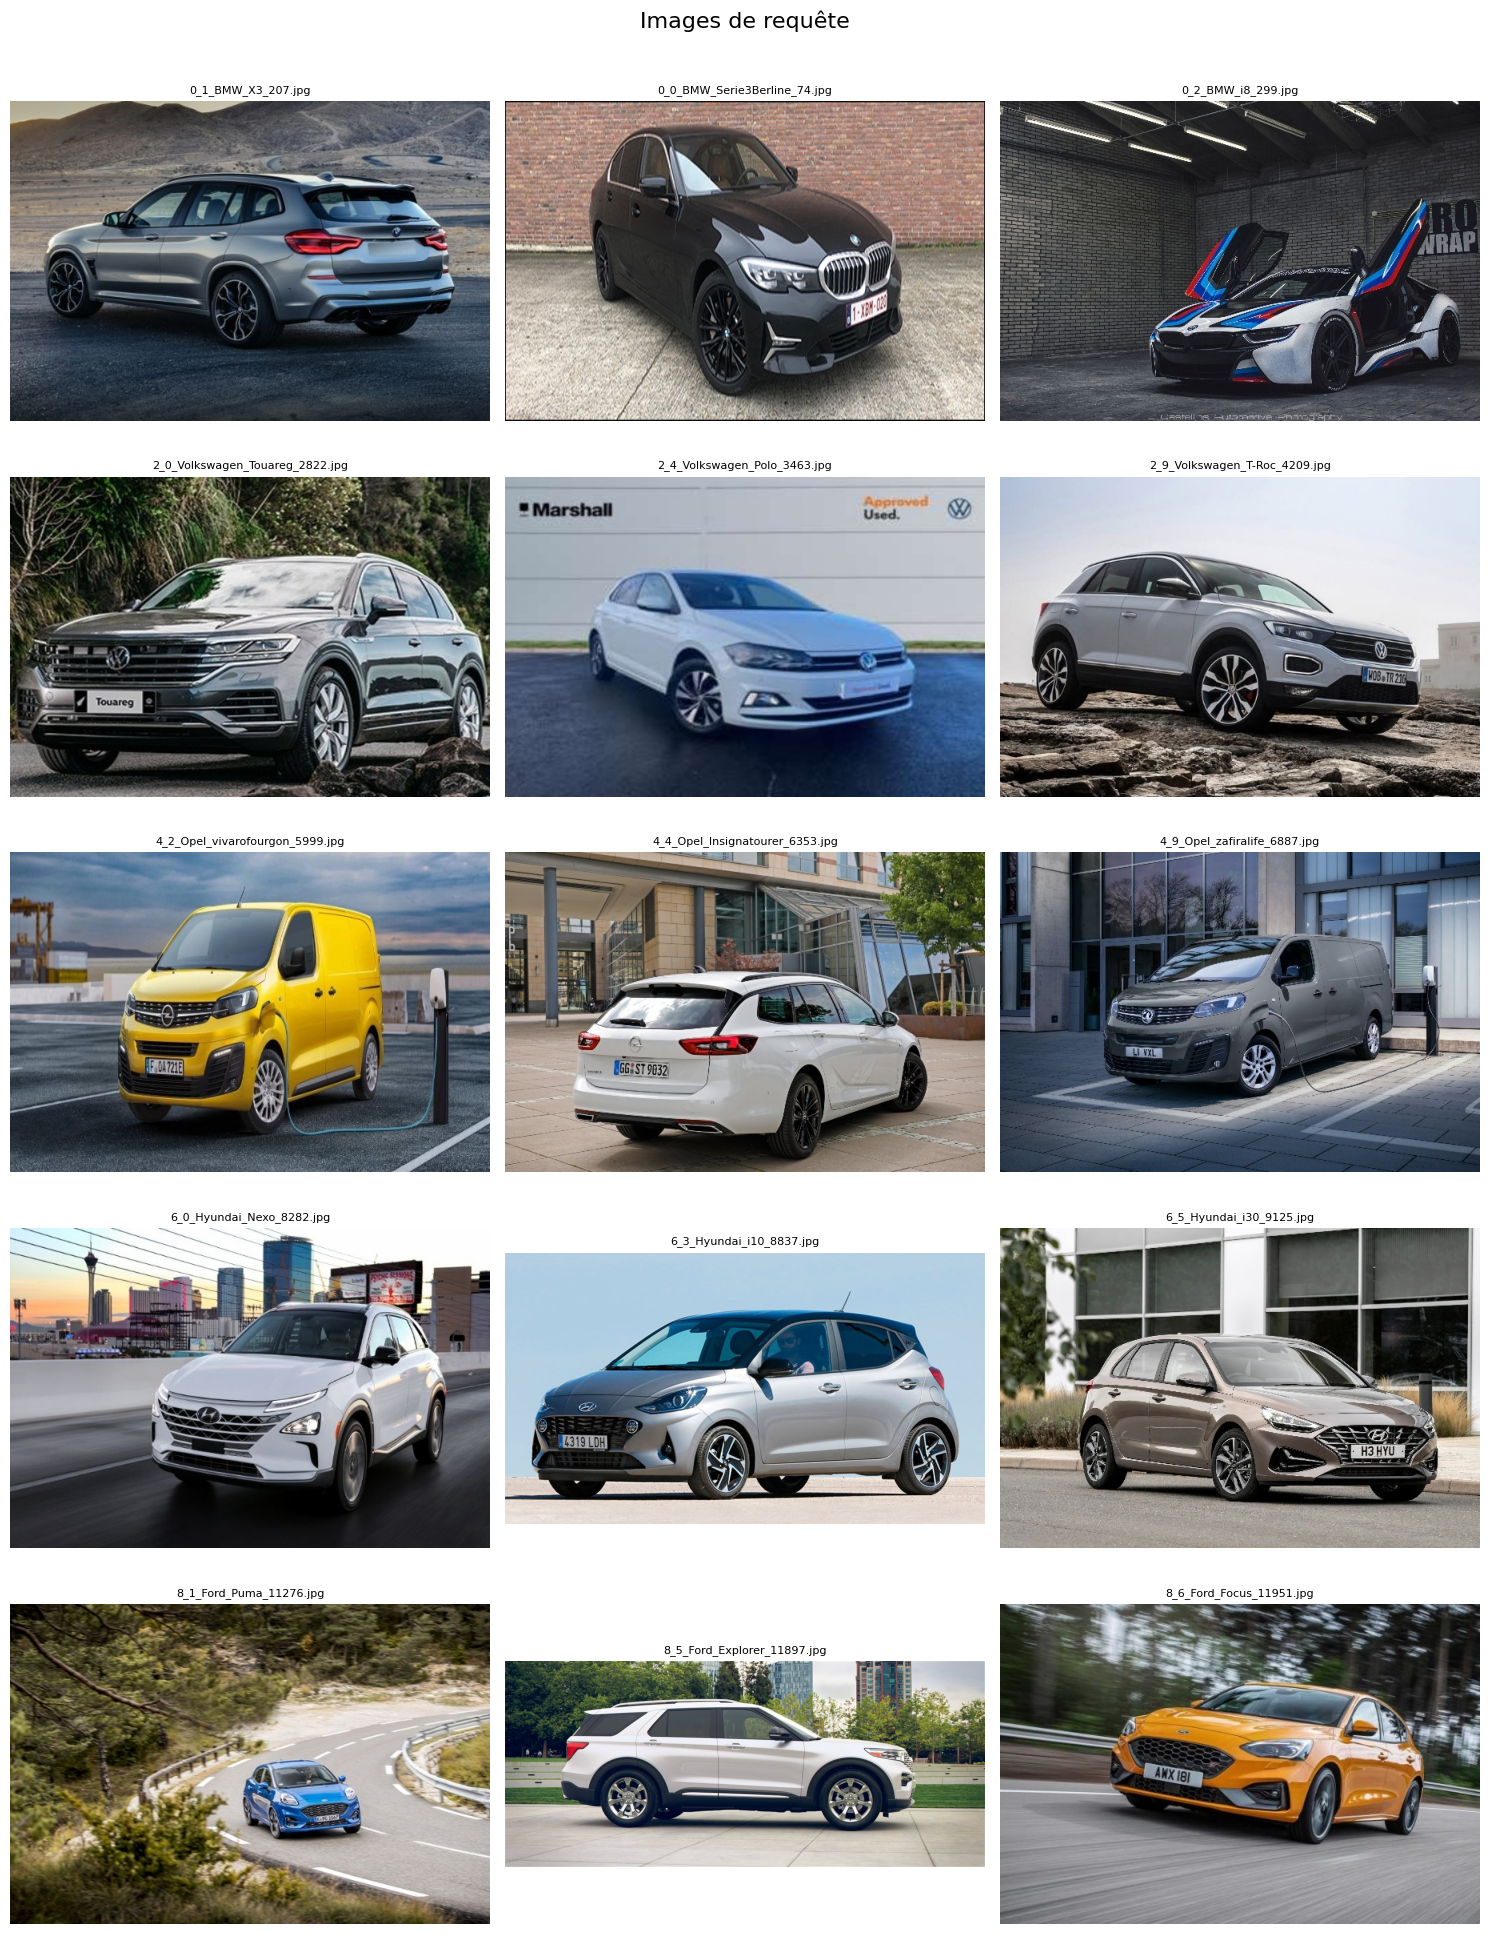

In [4]:
# Dictionnaire des requêtes spécifiques aux groupes impairs (1, 3, 5, 7, 9)
queries = {
    "Classe 0": ["0_1_BMW_X3_207.jpg", "0_0_BMW_Serie3Berline_74.jpg", "0_2_BMW_i8_299.jpg"],
    "Classe 2": ["2_0_Volkswagen_Touareg_2822.jpg", "2_4_Volkswagen_Polo_3463.jpg", "2_9_Volkswagen_T-Roc_4209.jpg"],
    "Classe 4": ["4_2_Opel_vivarofourgon_5999.jpg", "4_4_Opel_Insignatourer_6353.jpg", "4_9_Opel_zafiralife_6887.jpg"],
    "Classe 6": ["6_0_Hyundai_Nexo_8282.jpg", "6_3_Hyundai_i10_8837.jpg", "6_5_Hyundai_i30_9125.jpg"],
    "Classe 8": ["8_1_Ford_Puma_11276.jpg", "8_5_Ford_Explorer_11897.jpg", "8_6_Ford_Focus_11951.jpg"]
}

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
fig.suptitle("Images de requête", fontsize=16)

row_idx = 0
for class_name, images in queries.items():
    for col_idx, image_name in enumerate(images):
        img_path = os.path.join(DATA_DIR, image_name)
        
        ax = axes[row_idx, col_idx]
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(image_name, fontsize=8)
        else:
            ax.text(0.5, 0.5, f'Introuvable\n{image_name}', ha='center', va='center', fontsize=8, color='red')
        ax.axis('off')
    row_idx += 1

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

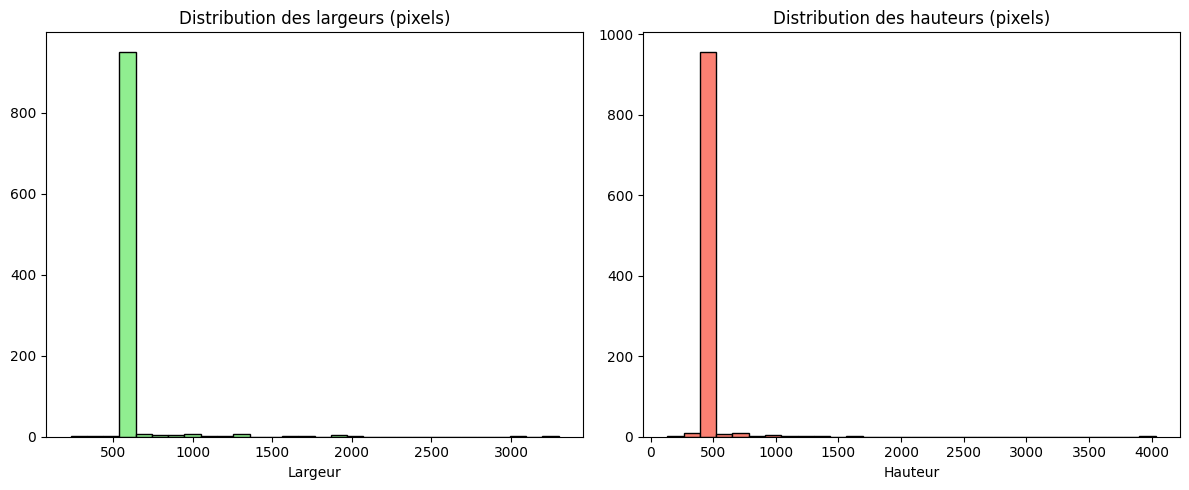

Résolution moyenne : 628 x 416 pixels


In [5]:
import random
sample_images = random.sample(all_images, min(1000, len(all_images)))

widths, heights = [], []

for img_name in sample_images:
    img_path = os.path.join(DATA_DIR, img_name)
    try:
        with Image.open(img_path) as img:
            widths.append(img.width)
            heights.append(img.height)
    except Exception as e:
        print(f"Erreur avec l'image {img_name}: {e}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=30, color='lightgreen', edgecolor='black')
plt.title("Distribution des largeurs (pixels)")
plt.xlabel("Largeur")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, color='salmon', edgecolor='black')
plt.title("Distribution des hauteurs (pixels)")
plt.xlabel("Hauteur")

plt.tight_layout()
plt.show()

print(f"Résolution moyenne : {int(sum(widths)/len(widths))} x {int(sum(heights)/len(heights))} pixels")

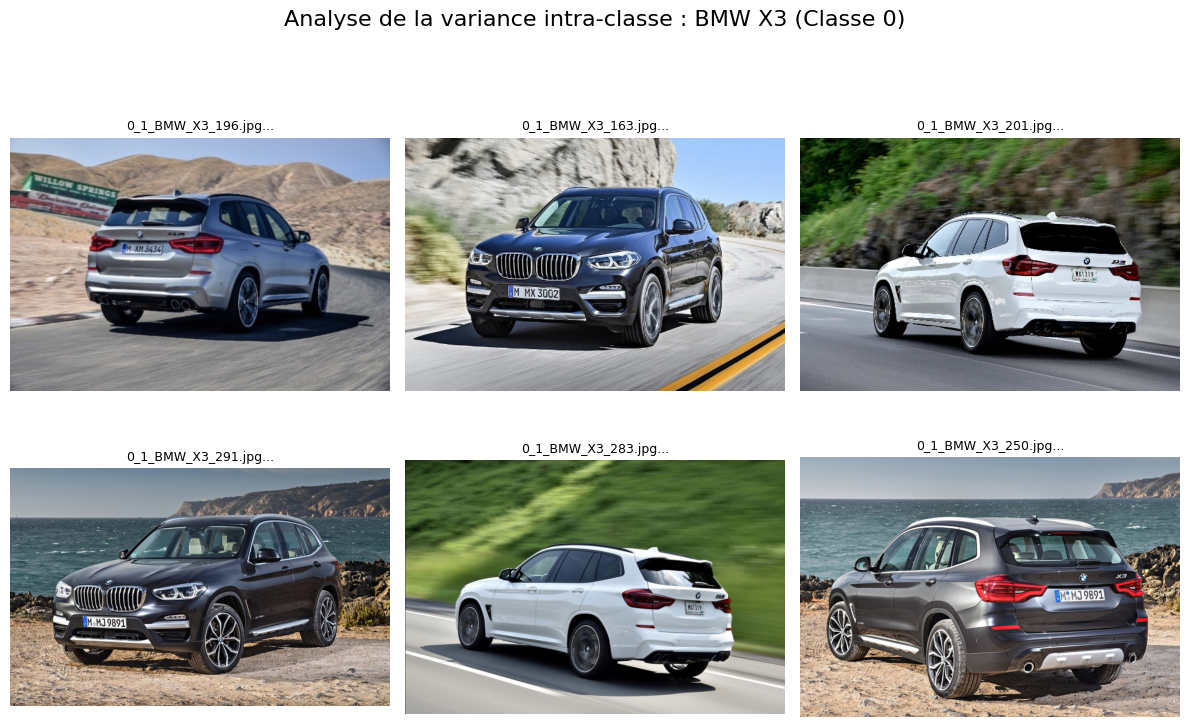

In [8]:
target_prefix = "0_1_"

bmw_x3_images = [img for img in all_images if img.startswith(target_prefix)]

sample_bmw = random.sample(bmw_x3_images, min(6, len(bmw_x3_images)))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Analyse de la variance intra-classe : BMW X3 (Classe 0)", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(sample_bmw):
        img_path = os.path.join(DATA_DIR, sample_bmw[i])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(sample_bmw[i][:20] + "...", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


## 4. Exploration de la base Multimodale "Flickr8K" (Partie II)

Cette base contient 8 000 images et 5 descriptions par image.
Vérifions le chargement du texte et affichons un exemple pour bien comprendre l'alignement entre les deux modalités.

In [9]:
import random

FLICKR_IMG_DIR = "../data/raw/Flickr8k_dataset/Images"
FLICKR_TEXT_FILE = "../data/raw/Flickr8k_dataset/captions.txt" 

if not os.path.exists(FLICKR_TEXT_FILE) or not os.path.exists(FLICKR_IMG_DIR):
    print("ERREUR : Les fichiers Flickr8K sont introuvables.")
    print("Assurez-vous d'avoir téléchargé le dataset depuis le repo GitHub.")
else:
    df_captions = pd.read_csv(FLICKR_TEXT_FILE, sep=',') 
    
    total_images = df_captions['image'].nunique()
    total_captions = len(df_captions)
    
    print(f"Fichier texte chargé !")
    print(f"Nombre d'images uniques : {total_images} (Attendu : ~8 000)")
    print(f"Nombre total de descriptions : {total_captions} (Attendu : ~40 000)")

Fichier texte chargé !
Nombre d'images uniques : 8091 (Attendu : ~8 000)
Nombre total de descriptions : 40455 (Attendu : ~40 000)


## 5. Visualisation d'une image et de ses 5 descriptions

L'objectif de CLIP sera de lier mathématiquement cette image à ces phrases. Regardons un exemple au hasard.

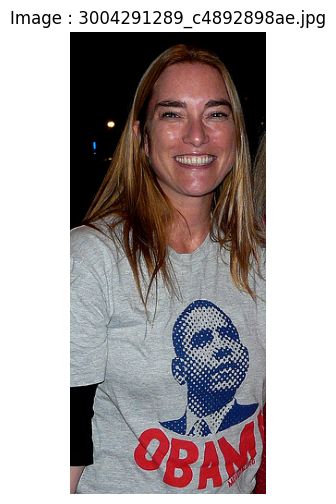

--------------------------------------------------
Descriptions associées à cette image :
--------------------------------------------------
1. a blonde haired girl in an Obama t-shirt is smiling at the camera .
2. A girl with long hair wearing an Obama t-shirt .
3. a woman wearing a t-shirt that says Obama
4. A young women wears an " Obama " t-shirt .
5. Woman in Obama t-shirt smiling .


In [10]:
if os.path.exists(FLICKR_TEXT_FILE) and os.path.exists(FLICKR_IMG_DIR):
    sample_img_name = random.choice(df_captions['image'].unique())
    
    sample_captions = df_captions[df_captions['image'] == sample_img_name]['caption'].tolist()
    
    img_path = os.path.join(FLICKR_IMG_DIR, sample_img_name)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image : {sample_img_name}", fontsize=12)
        plt.show()
        
        print("-" * 50)
        print("Descriptions associées à cette image :")
        print("-" * 50)
        for i, caption in enumerate(sample_captions, 1):
            print(f"{i}. {caption}")
    else:
        print(f"Impossible de charger l'image {sample_img_name}.")

Descriptions manquantes (NaN) : 0


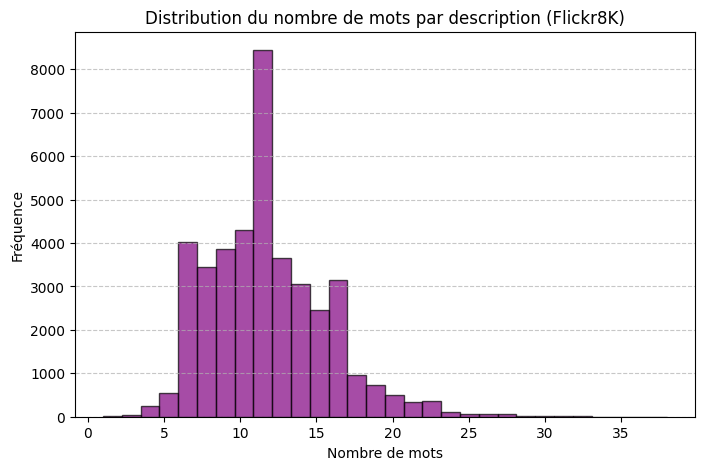

Nombre de mots - Min: 1, Max: 38, Moyenne: 11.8
Toutes les descriptions sont courtes et passeront sans problème dans l'encodeur de CLIP.


In [11]:
if 'df_captions' in locals():
    missing_captions = df_captions['caption'].isnull().sum()
    print(f"Descriptions manquantes (NaN) : {missing_captions}")
    
    df_captions['word_count'] = df_captions['caption'].astype(str).apply(lambda x: len(x.split()))
    
    plt.figure(figsize=(8, 5))
    plt.hist(df_captions['word_count'], bins=30, color='purple', edgecolor='black', alpha=0.7)
    plt.title("Distribution du nombre de mots par description (Flickr8K)")
    plt.xlabel("Nombre de mots")
    plt.ylabel("Fréquence")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Nombre de mots - Min: {df_captions['word_count'].min()}, Max: {df_captions['word_count'].max()}, Moyenne: {df_captions['word_count'].mean():.1f}")
    if df_captions['word_count'].max() < 70:
        print("Toutes les descriptions sont courtes et passeront sans problème dans l'encodeur de CLIP.")